In [1]:
# ==========================================
# IMPORT LIBRERIE GLOBALI E SETUP
# ==========================================
import os
import pandas as pd
import numpy as np
import networkx as nx
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Parametri Generali
TARGET_GENE = 'KRAS'
COORTI = ["kras_pancreas", "kras_lung", "kras_colon","colon","lung","pancreas"]
INPUT_BASE_DIR = "./data_filtered"
OUTPUT_STRAT_DIR = "./data_stratified"

OMIC_MODE = "MUT_ONLY" # Opzioni supportate: "MUT_ONLY" oppure "ALL_OMICS"

os.makedirs(OUTPUT_STRAT_DIR, exist_ok=True)
print(f"✅ Ambiente configurato. Modalità Omica: {OMIC_MODE}")

✅ Ambiente configurato. Modalità Omica: MUT_ONLY


# FUNZIONI SURVIVAL ANALYSIS

In [2]:
# ==========================================
# SURVIVAL ANALYSIS
# ==========================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

def load_mutation_matrix(coorte):
    """
    Carica la matrice binaria M_binary (Righe: Sample_id, Colonne: Geni).
    """
    path_mut = f"./outputs_mut/{coorte}/matrices/M_binary_{coorte}.tsv"
    if os.path.exists(path_mut):
        # index_col=0 carica il Sample_id come indice per facilitare il mapping
        df_mut = pd.read_csv(path_mut, sep='\t', index_col=0)
        return df_mut
    else:
        print(f"[-] Matrice mutazionale non trovata: {path_mut}")
        return None

def plot_kaplan_meier(df_clinical, group_col, time_col='Overall Survival (Months)', status_col='Overall Survival Status', ax=None):
    """
    Esegue l'analisi di Kaplan-Meier e calcola il modello di Cox su un asse specifico (ax).
    """
    # Pulizia nomi colonne
    df_clinical.columns = df_clinical.columns.str.strip()
    
    # Pulizia dati: 1 se DECEASED, 0 se LIVING
    df_clean = df_clinical.dropna(subset=[time_col, status_col, group_col]).copy()
    df_clean['Time'] = pd.to_numeric(df_clean[time_col], errors='coerce')
    df_clean['Event'] = df_clean[status_col].apply(lambda x: 1 if '1:DECEASED' in str(x).upper() else 0)
    df_clean = df_clean.dropna(subset=['Time'])

    if df_clean.empty or len(df_clean[group_col].unique()) < 2:
        if ax: ax.text(0.5, 0.5, "Dati insufficienti\n(min. 2 gruppi)", ha='center')
        return

    kmf = KaplanMeierFitter()
    
    if ax is None:
        plt.figure(figsize=(8, 5))
        ax = plt.gca()

    groups = df_clean[group_col].unique()
    durations, events = [], []

    for group in groups:
        mask = (df_clean[group_col] == group)
        t, e = df_clean[mask]['Time'], df_clean[mask]['Event']
        if len(t) > 5: # Soglia minima di pazienti per gruppo
            kmf.fit(t, event_observed=e, label=f"{group} (n={len(t)})")
            kmf.plot_survival_function(ax=ax, ci_show=False) # ci_show=False per pulizia nei subplots
            durations.append(t); events.append(e)

    ax.set_title(f"{group_col}", fontweight='bold')
    ax.set_xlabel("Mesi")
    ax.set_ylabel("Probabilità di Sopravvivenza")
    ax.grid(True, alpha=0.3)
    ax.legend(prop={'size': 9})

    # Test statistico (Log-rank) e Modello di Cox
    if len(durations) == 2:
        # 1. Log-rank test
        res = logrank_test(durations[0], durations[1], event_observed_A=events[0], event_observed_B=events[1])
        
        # 2. Cox Proportional Hazards (HR)
        df_cox = df_clean[[group_col, 'Time', 'Event']].copy()
        
        # Mappiamo il primo gruppo trovato come 1 e il secondo come 0 per la regressione
        g1, g0 = groups[0], groups[1]
        df_cox['Group_Num'] = np.where(df_cox[group_col] == g1, 1, 0)
        df_cox = df_cox[['Group_Num', 'Time', 'Event']]
        
        cph = CoxPHFitter()
        try:
            # Fit del modello sui due gruppi
            cph.fit(df_cox, duration_col='Time', event_col='Event')
            
            # Estrazione valori dalla tabella dei risultati (summary)
            hr = cph.summary.loc['Group_Num', 'exp(coef)']
            ci_lower = cph.summary.loc['Group_Num', 'exp(coef) lower 95%']
            ci_upper = cph.summary.loc['Group_Num', 'exp(coef) upper 95%']
            
            # Stringa combinata con Log-Rank e Hazard Ratio
            stats_text = (f"Log-rank p-value = {res.p_value:.4f}\n"
                          f"HR ({g1} vs {g0}) = {hr:.2f}\n"
                          f"95% CI: {ci_lower:.2f} - {ci_upper:.2f}")
        except Exception as e:
            # Se la regressione di Cox fallisce (es. convergenza non raggiunta), mostra solo il log-rank
            stats_text = f"Log-rank p-value = {res.p_value:.4f}"
            
        # Aggiunta del riquadro informativo sul grafico in basso a sinistra
        ax.annotate(stats_text, xy=(0.05, 0.05), xycoords='axes fraction', 
                     fontsize=9, bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.9))

def survival_by_gene_hub(df_clinical, df_mut, gene_name, ax=None):
    """
    Incrocia la clinica con lo stato mutazionale di un gene.
    """
    df_plot = df_clinical.copy()
    df_plot['Sample_Id'] = df_plot['Sample_Id'].astype(str)
    
    if gene_name not in df_mut.columns:
        if ax: ax.text(0.5, 0.5, f"Gene {gene_name}\nnon in matrice", ha='center')
        return

    # Match tramite l'indice della matrice mutazionale (Sample_id)
    gene_status = df_mut[gene_name].to_dict()
    df_plot['Gene_Status'] = df_plot['Sample_Id'].map(gene_status)
    
    # Crea un raggruppamento per il plot
    df_plot['Gene_Group'] = df_plot['Gene_Status'].map({1.0: f'{gene_name} Mut', 0.0: f'{gene_name} WT'})
    df_plot = df_plot.dropna(subset=['Gene_Group'])
    
    plot_kaplan_meier(df_plot, group_col='Gene_Group', ax=ax)

# PRIMA ANALISI GENERALE SU UNA FEATURE SULL'ENRICHMENT GLOBALE

Ecco tutte le possibili colonne: ['Study ID', 'Patient ID', 'Sample_Id', 'Tumor Site: Adrenal Glands (NLP)', 'Tumor Site: Bone (NLP)', 'Cancer Type', 'Cancer Type Detailed', 'Clinical Group', 'Clinical Summary', 'Tumor Site: CNS/Brain (NLP)', 'Current Age', 'Diagnosis Description', 'Ethnicity', 'Fraction Genome Altered', 'Sex', 'Gene Panel', 'Gleason Score, 1st Reported (NLP)', 'Gleason Score, Highest Reported (NLP)', 'Gleason Score Reported on Sample (NLP)', 'HER2', 'History for Positive PD-L1 (NLP)', 'HR', 'ICD-O Histology Description', 'Tumor Site: Intra Abdominal', 'Tumor Site: Liver (NLP)', 'Tumor Site: Lung (NLP)', 'Tumor Site: Lymph Node (NLP)', 'Metastatic Site', 'MSI Comment', 'MSI Score', 'MSI Type', 'Mutation Count', 'Number of Tumor Registry Entries', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'Tumor Site: Other (NLP)', 'Pathological Group', 'Sample PD-L1 Positive (NLP)', 'Tumor Site: Pleura (NLP)', 'Primary Tumor Site', 'Prior Treatment to MSK

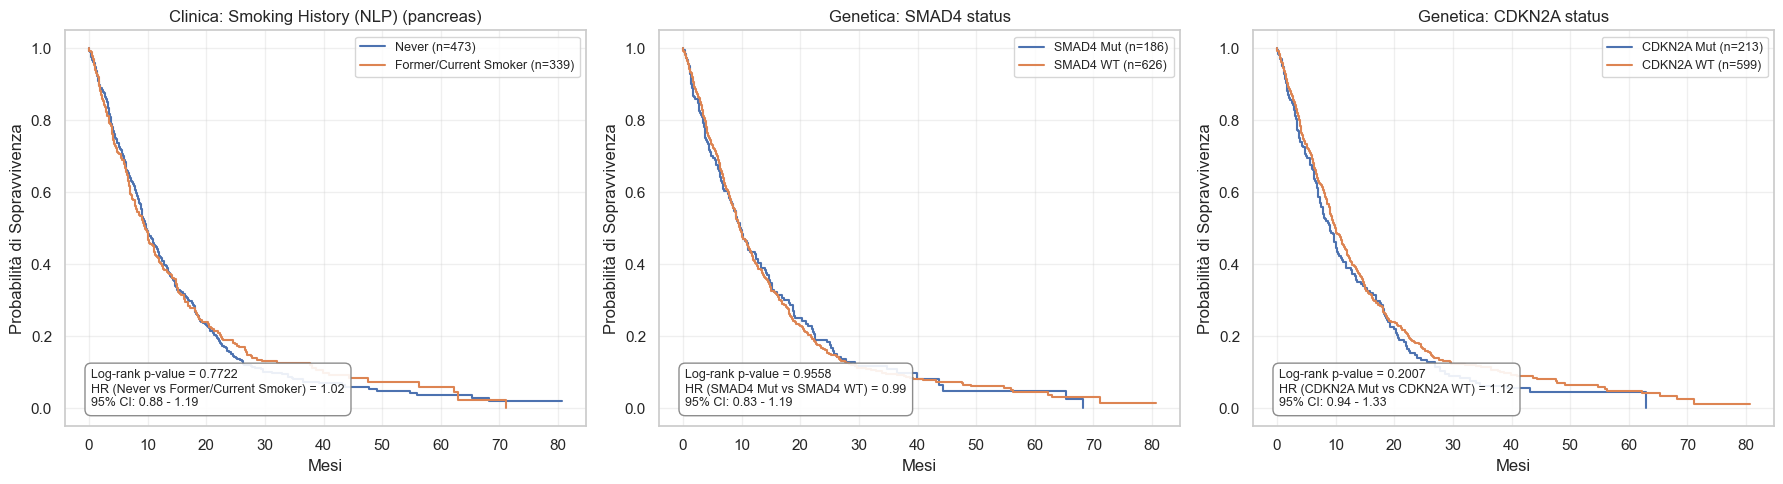

Ecco tutte le possibili colonne: ['Study ID', 'Patient ID', 'Sample_Id', 'Tumor Site: Adrenal Glands (NLP)', 'Tumor Site: Bone (NLP)', 'Cancer Type', 'Cancer Type Detailed', 'Clinical Group', 'Clinical Summary', 'Tumor Site: CNS/Brain (NLP)', 'Current Age', 'Diagnosis Description', 'Ethnicity', 'Fraction Genome Altered', 'Sex', 'Gene Panel', 'Gleason Score, 1st Reported (NLP)', 'Gleason Score, Highest Reported (NLP)', 'Gleason Score Reported on Sample (NLP)', 'HER2', 'History for Positive PD-L1 (NLP)', 'HR', 'ICD-O Histology Description', 'Tumor Site: Intra Abdominal', 'Tumor Site: Liver (NLP)', 'Tumor Site: Lung (NLP)', 'Tumor Site: Lymph Node (NLP)', 'Metastatic Site', 'MSI Comment', 'MSI Score', 'MSI Type', 'Mutation Count', 'Number of Tumor Registry Entries', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'Tumor Site: Other (NLP)', 'Pathological Group', 'Sample PD-L1 Positive (NLP)', 'Tumor Site: Pleura (NLP)', 'Primary Tumor Site', 'Prior Treatment to MSK

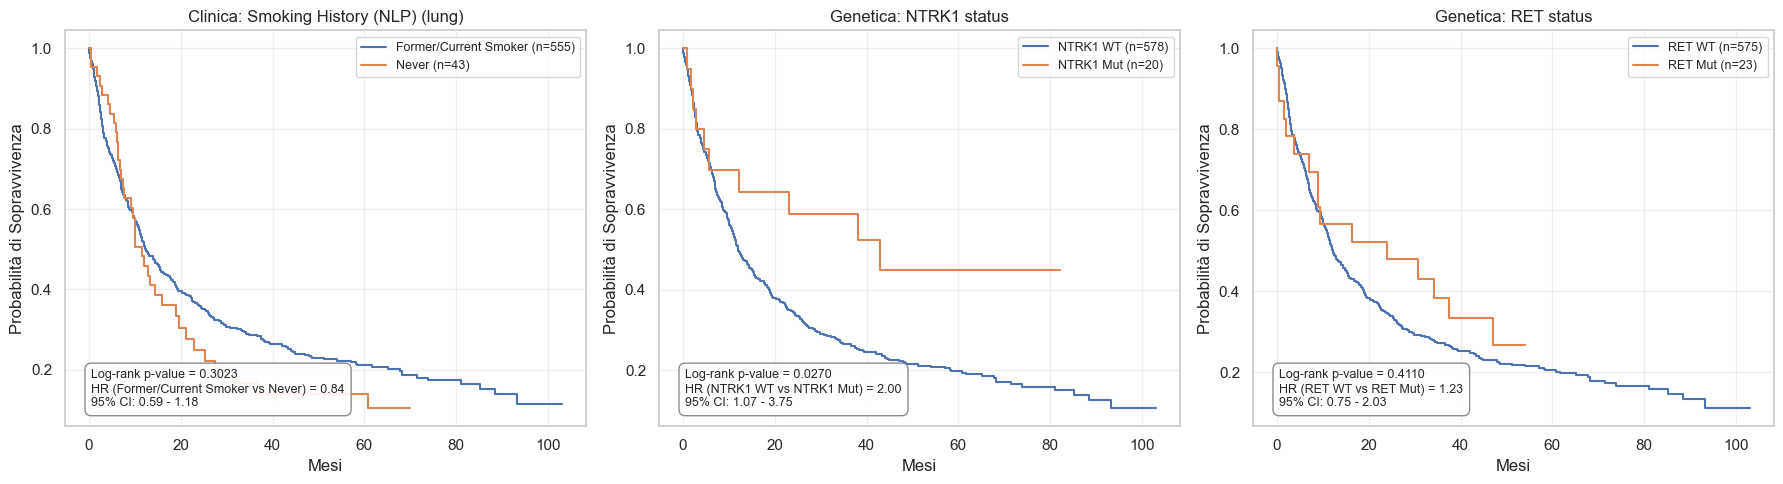

Ecco tutte le possibili colonne: ['Study ID', 'Patient ID', 'Sample_Id', 'Tumor Site: Adrenal Glands (NLP)', 'Tumor Site: Bone (NLP)', 'Cancer Type', 'Cancer Type Detailed', 'Clinical Group', 'Clinical Summary', 'Tumor Site: CNS/Brain (NLP)', 'Current Age', 'Diagnosis Description', 'Ethnicity', 'Fraction Genome Altered', 'Sex', 'Gene Panel', 'Gleason Score, 1st Reported (NLP)', 'Gleason Score, Highest Reported (NLP)', 'Gleason Score Reported on Sample (NLP)', 'HER2', 'History for Positive PD-L1 (NLP)', 'HR', 'ICD-O Histology Description', 'Tumor Site: Intra Abdominal', 'Tumor Site: Liver (NLP)', 'Tumor Site: Lung (NLP)', 'Tumor Site: Lymph Node (NLP)', 'Metastatic Site', 'MSI Comment', 'MSI Score', 'MSI Type', 'Mutation Count', 'Number of Tumor Registry Entries', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'Tumor Site: Other (NLP)', 'Pathological Group', 'Sample PD-L1 Positive (NLP)', 'Tumor Site: Pleura (NLP)', 'Primary Tumor Site', 'Prior Treatment to MSK

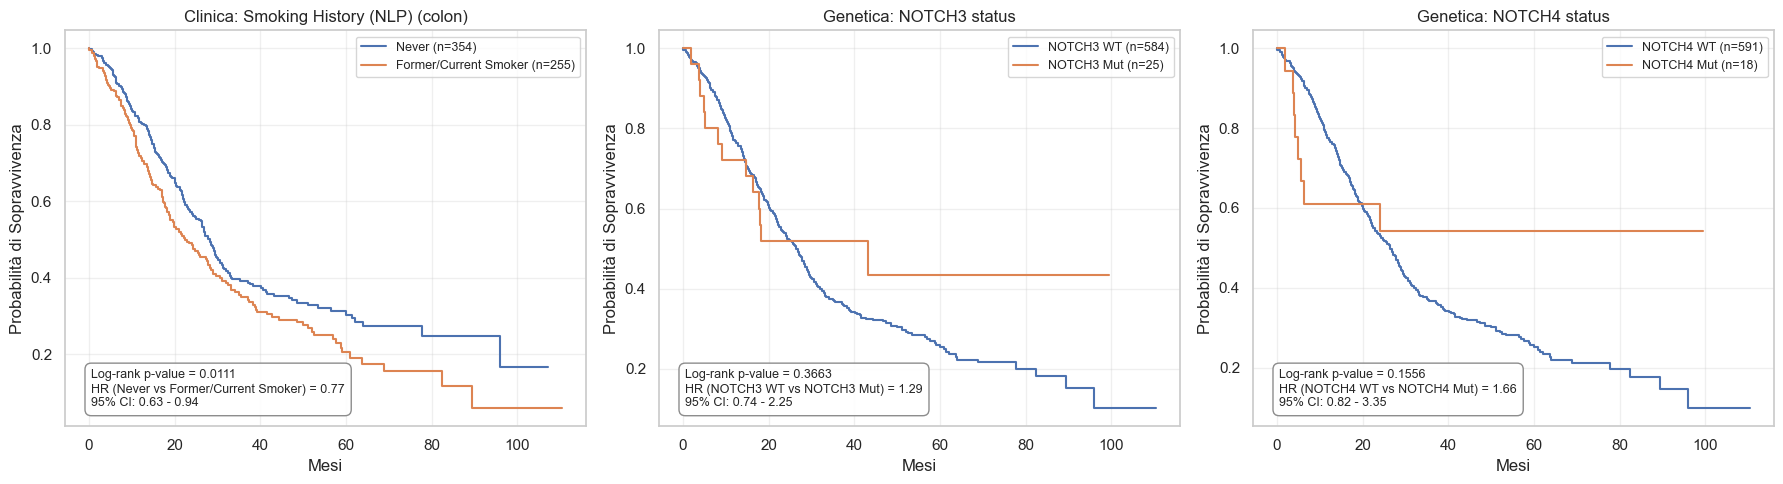

Ecco tutte le possibili colonne: ['Study ID', 'Patient ID', 'Sample_Id', 'Tumor Site: Adrenal Glands (NLP)', 'Tumor Site: Bone (NLP)', 'Cancer Type', 'Cancer Type Detailed', 'Clinical Group', 'Clinical Summary', 'Tumor Site: CNS/Brain (NLP)', 'Current Age', 'Diagnosis Description', 'Ethnicity', 'Fraction Genome Altered', 'Sex', 'Gene Panel', 'Gleason Score, 1st Reported (NLP)', 'Gleason Score, Highest Reported (NLP)', 'Gleason Score Reported on Sample (NLP)', 'HER2', 'History for Positive PD-L1 (NLP)', 'HR', 'ICD-O Histology Description', 'Tumor Site: Intra Abdominal', 'Tumor Site: Liver (NLP)', 'Tumor Site: Lung (NLP)', 'Tumor Site: Lymph Node (NLP)', 'Metastatic Site', 'MSI Comment', 'MSI Score', 'MSI Type', 'Mutation Count', 'Number of Tumor Registry Entries', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'Tumor Site: Other (NLP)', 'Pathological Group', 'Sample PD-L1 Positive (NLP)', 'Tumor Site: Pleura (NLP)', 'Primary Tumor Site', 'Prior Treatment to MSK

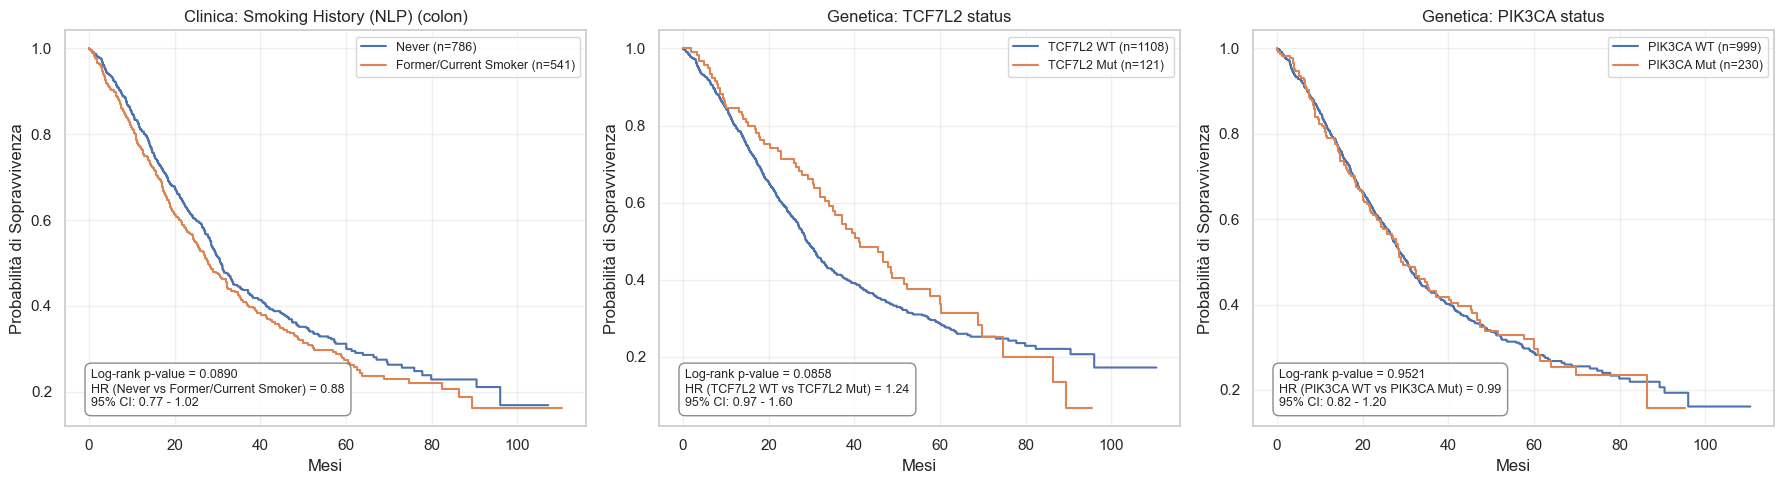

Ecco tutte le possibili colonne: ['Study ID', 'Patient ID', 'Sample_Id', 'Tumor Site: Adrenal Glands (NLP)', 'Tumor Site: Bone (NLP)', 'Cancer Type', 'Cancer Type Detailed', 'Clinical Group', 'Clinical Summary', 'Tumor Site: CNS/Brain (NLP)', 'Current Age', 'Diagnosis Description', 'Ethnicity', 'Fraction Genome Altered', 'Sex', 'Gene Panel', 'Gleason Score, 1st Reported (NLP)', 'Gleason Score, Highest Reported (NLP)', 'Gleason Score Reported on Sample (NLP)', 'HER2', 'History for Positive PD-L1 (NLP)', 'HR', 'ICD-O Histology Description', 'Tumor Site: Intra Abdominal', 'Tumor Site: Liver (NLP)', 'Tumor Site: Lung (NLP)', 'Tumor Site: Lymph Node (NLP)', 'Metastatic Site', 'MSI Comment', 'MSI Score', 'MSI Type', 'Mutation Count', 'Number of Tumor Registry Entries', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'Tumor Site: Other (NLP)', 'Pathological Group', 'Sample PD-L1 Positive (NLP)', 'Tumor Site: Pleura (NLP)', 'Primary Tumor Site', 'Prior Treatment to MSK

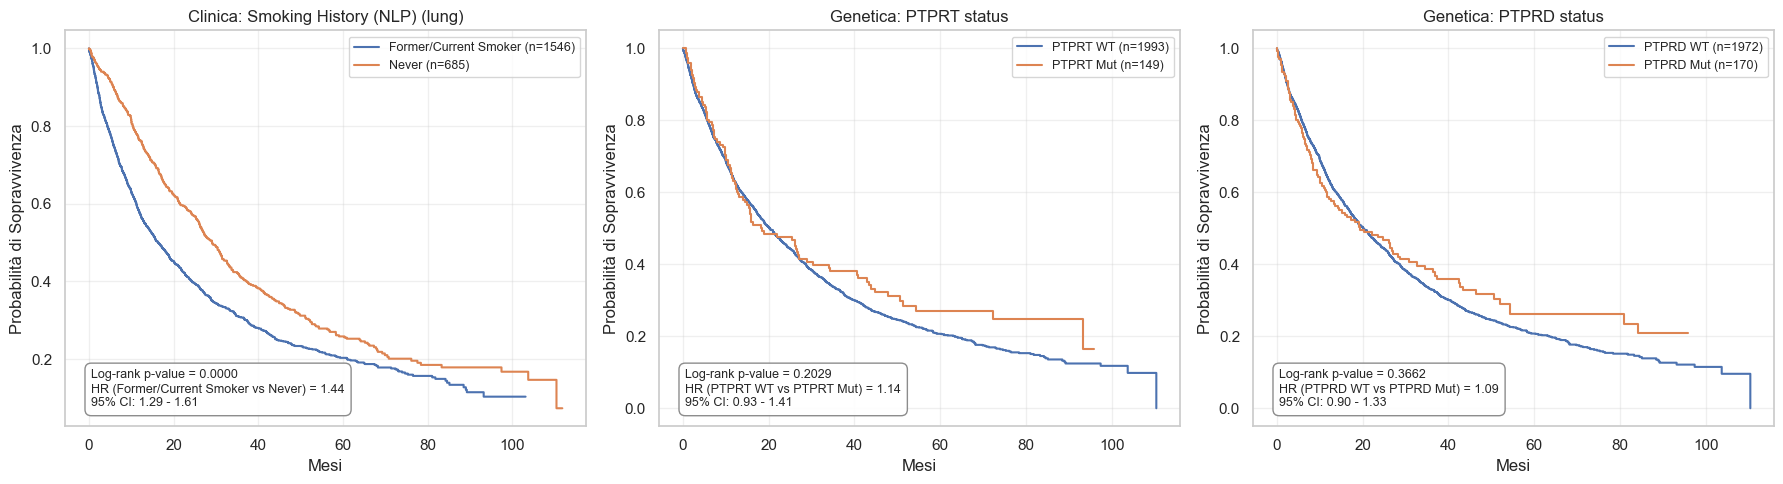

Ecco tutte le possibili colonne: ['Study ID', 'Patient ID', 'Sample_Id', 'Tumor Site: Adrenal Glands (NLP)', 'Tumor Site: Bone (NLP)', 'Cancer Type', 'Cancer Type Detailed', 'Clinical Group', 'Clinical Summary', 'Tumor Site: CNS/Brain (NLP)', 'Current Age', 'Diagnosis Description', 'Ethnicity', 'Fraction Genome Altered', 'Sex', 'Gene Panel', 'Gleason Score, 1st Reported (NLP)', 'Gleason Score, Highest Reported (NLP)', 'Gleason Score Reported on Sample (NLP)', 'HER2', 'History for Positive PD-L1 (NLP)', 'HR', 'ICD-O Histology Description', 'Tumor Site: Intra Abdominal', 'Tumor Site: Liver (NLP)', 'Tumor Site: Lung (NLP)', 'Tumor Site: Lymph Node (NLP)', 'Metastatic Site', 'MSI Comment', 'MSI Score', 'MSI Type', 'Mutation Count', 'Number of Tumor Registry Entries', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'Tumor Site: Other (NLP)', 'Pathological Group', 'Sample PD-L1 Positive (NLP)', 'Tumor Site: Pleura (NLP)', 'Primary Tumor Site', 'Prior Treatment to MSK

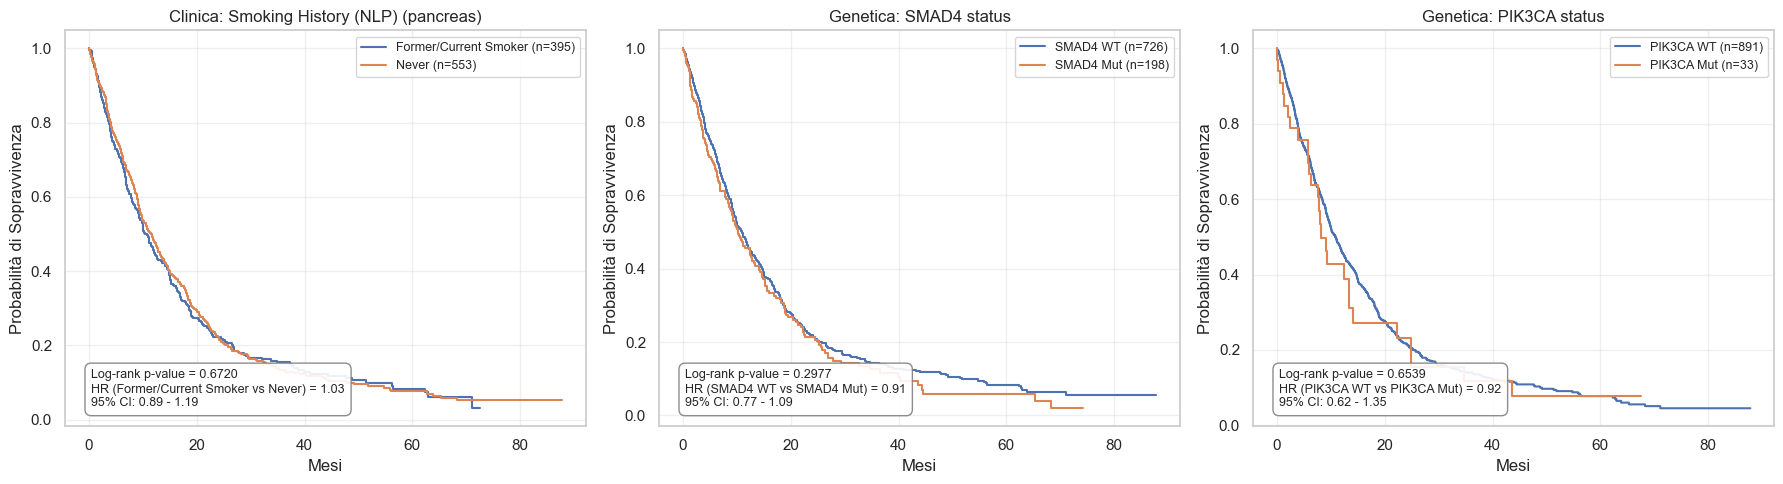

In [3]:

FEATURE_ANALIZZATA= 'Smoking History (NLP)' #


for coorte in COORTI:
    if "kras_" in coorte:
        coorte_base = coorte.replace("kras_", "")
        path_clinical = f"./data_filtered/{coorte}/KRAS_F_{coorte_base}.csv"
        path_enrich = f"./outputs_mut/{coorte}/intracluster/Hubs_Global_Enrichment_FULL_{coorte}.tsv"
    else:
        coorte_base = coorte
        path_clinical = f"./data_filtered/{coorte}/F_{coorte_base}.csv"
        path_enrich = f"./outputs_mut/{coorte}/intracluster/Hubs_Global_Enrichment_FULL_{coorte}.tsv"
    
    if os.path.exists(path_clinical):
        df_clinical = pd.read_csv(path_clinical, sep='\t')
        print (f"Ecco tutte le possibili colonne: {df_clinical.columns.tolist()}")
        df_mut = load_mutation_matrix(coorte)
        
        if df_mut is not None:
            # 1. Recupero geni dal file di Enrichment (primi 2 geni del top pathway)
            genes_to_test = []
            if os.path.exists(path_enrich):
                df_enrich = pd.read_csv(path_enrich, sep='\t')
                if not df_enrich.empty:
                    # Estraiamo i geni separati da ';' e prendiamo i primi due
                    genes_to_test = str(df_enrich.iloc[0]['Genes']).split(';')[:2]

            # 2. Creazione della riga di grafici (1 riga, 3 colonne)
            print(f"\n📊 GENERANDO ANALISI PER: {coorte.upper()}")
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            
            # --- Colonna 0: Clinica (Sesso) ---
            plot_kaplan_meier(df_clinical, group_col=FEATURE_ANALIZZATA, ax=axes[0])
            axes[0].set_title(f"Clinica: {FEATURE_ANALIZZATA} ({coorte_base})")
            
            # --- Colonne 1 e 2: Geni Hub ---
            for i in range(2):
                target_ax = axes[i+1]
                if i < len(genes_to_test):
                    gene = genes_to_test[i]
                    survival_by_gene_hub(df_clinical, df_mut, gene, ax=target_ax)
                    target_ax.set_title(f"Genetica: {gene} status")
                else:
                    target_ax.axis('off') # Nascondi se non ci sono geni

            plt.tight_layout()
            plt.show()

    else:
        print(f"[-] File clinico non trovato: {path_clinical}")

# SIGNIFICATIVITA' CLUSTER

🚀 Avvio scansione clinica sui Cluster di Leiden...

═══════════════════════════════════════════════════════════════════════════
 🧬 ANALISI SIGNIFICATIVITÀ CLUSTER: KRAS_PANCREAS
═══════════════════════════════════════════════════════════════════════════
 ❌ NON SIG. | CLUSTER 0
    - P-Value: 0.17022
    - Rischio  : HR = 1.17 (95% CI: 0.94 - 1.45) [Mutati vs WT]
    - Effetto  : Nessun effetto sul rischio (Il CI include l'1 ⚪)
    - Hubs     : ['ARID1A', 'KMT2D', 'BRCA2']
    - Pazienti : Mutati=112, Wild-Type=700
---------------------------------------------------------------------------
 ❌ NON SIG. | CLUSTER 1
    - P-Value: 0.83878
    - Rischio  : HR = 1.02 (95% CI: 0.85 - 1.22) [Mutati vs WT]
    - Effetto  : Nessun effetto sul rischio (Il CI include l'1 ⚪)
    - Hubs     : ['SMAD4', 'PREX2', 'AKT3']
    - Pazienti : Mutati=197, Wild-Type=615
---------------------------------------------------------------------------
 ❌ NON SIG. | CLUSTER 2
    - P-Value: 0.97042
    - Rischio  : 

<Figure size 800x500 with 0 Axes>

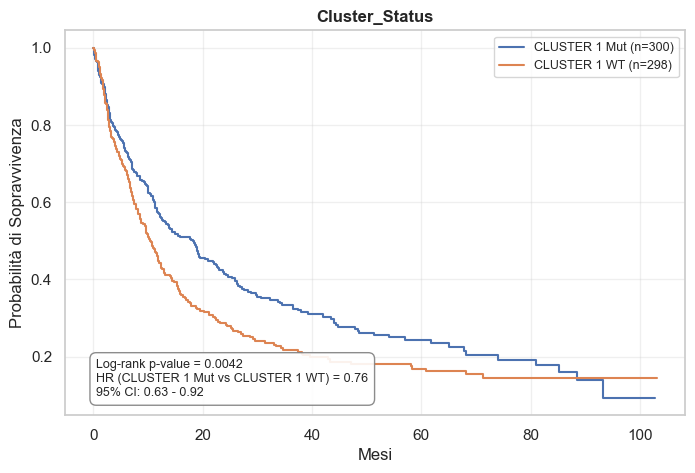

 ✅ SIGNIFICATIVO | CLUSTER 2
    - P-Value: 0.00000
    - Rischio  : HR = 1.95 (95% CI: 1.62 - 2.36) [Mutati vs WT]
    - Effetto  : Rischio aumentato (Fattore prognostico negativo 🔴)
    - Hubs     : ['KEAP1', 'SMARCA4', 'STK11']
    - Pazienti : Mutati=249, Wild-Type=349
---------------------------------------------------------------------------


<Figure size 800x500 with 0 Axes>

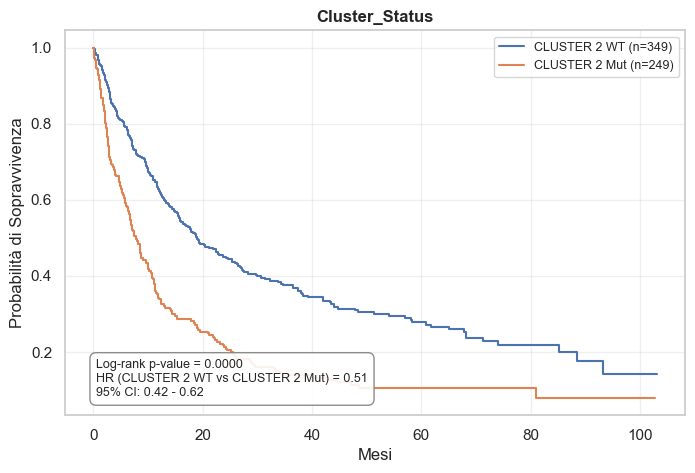

 ✅ SIGNIFICATIVO | CLUSTER 3
    - P-Value: 0.00149
    - Rischio  : HR = 0.67 (95% CI: 0.52 - 0.86) [Mutati vs WT]
    - Effetto  : Rischio ridotto (Fattore protettivo 🟢)
    - Hubs     : ['ARID1A', 'MGA', 'SETD2']
    - Pazienti : Mutati=106, Wild-Type=492
---------------------------------------------------------------------------


<Figure size 800x500 with 0 Axes>

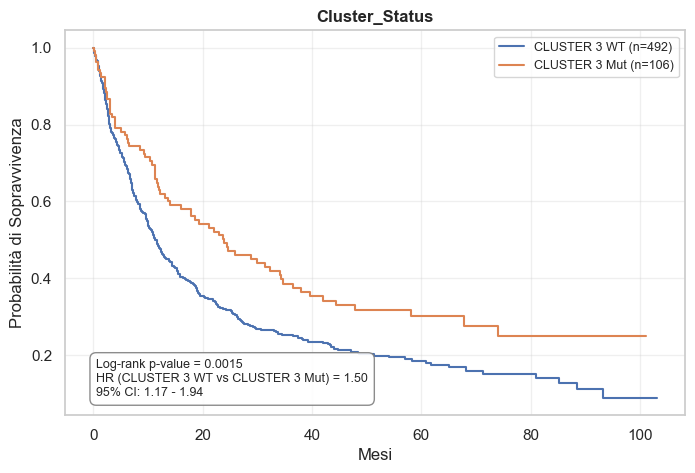

 ❌ NON SIG. | CLUSTER 4
    - P-Value: 0.54786
    - Rischio  : HR = 0.93 (95% CI: 0.73 - 1.18) [Mutati vs WT]
    - Effetto  : Nessun effetto sul rischio (Il CI include l'1 ⚪)
    - Hubs     : ['NTRK1', 'RBM10', 'GLI1']
    - Pazienti : Mutati=117, Wild-Type=481
---------------------------------------------------------------------------
 ❌ NON SIG. | CLUSTER 5
    - P-Value: 0.75809
    - Rischio  : HR = 0.95 (95% CI: 0.71 - 1.28) [Mutati vs WT]
    - Effetto  : Nessun effetto sul rischio (Il CI include l'1 ⚪)
    - Hubs     : ['ATRX', 'RET', 'CIC']
    - Pazienti : Mutati=66, Wild-Type=532
---------------------------------------------------------------------------

═══════════════════════════════════════════════════════════════════════════
 🧬 ANALISI SIGNIFICATIVITÀ CLUSTER: KRAS_COLON
═══════════════════════════════════════════════════════════════════════════
 ✅ SIGNIFICATIVO | CLUSTER 0
    - P-Value: 0.02062
    - Rischio  : HR = 0.64 (95% CI: 0.43 - 0.94) [Mutati vs WT]
    - Eff

<Figure size 800x500 with 0 Axes>

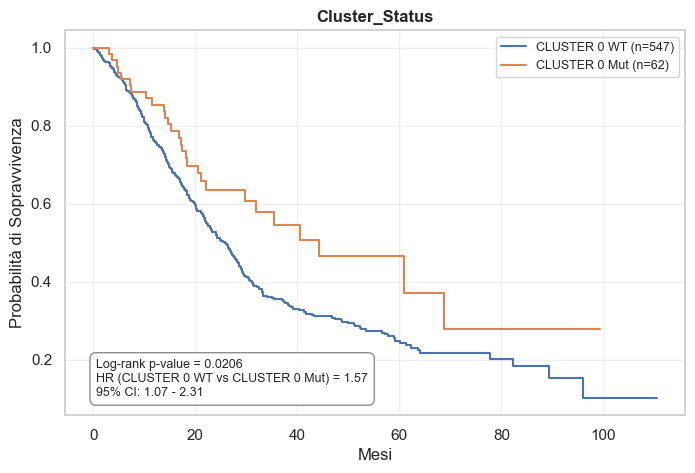

 ✅ SIGNIFICATIVO | CLUSTER 1
    - P-Value: 0.04398
    - Rischio  : HR = 0.62 (95% CI: 0.39 - 0.99) [Mutati vs WT]
    - Effetto  : Rischio ridotto (Fattore protettivo 🟢)
    - Hubs     : ['ARID2', 'EP300', 'NOTCH4']
    - Pazienti : Mutati=43, Wild-Type=566
---------------------------------------------------------------------------


<Figure size 800x500 with 0 Axes>

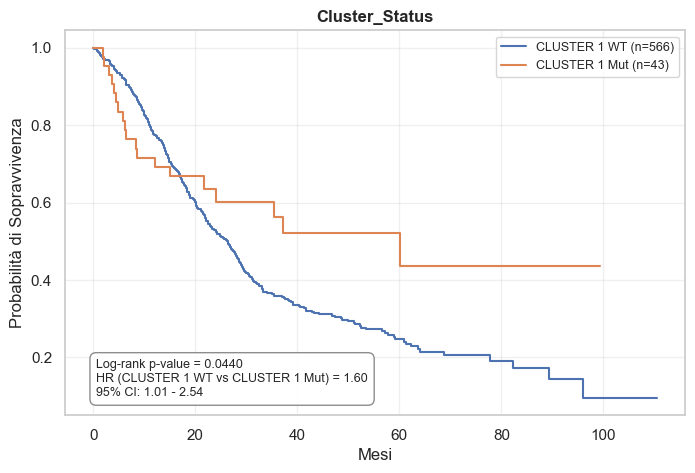

 ❌ NON SIG. | CLUSTER 2
    - P-Value: 0.67061
    - Rischio  : HR = 0.93 (95% CI: 0.65 - 1.31) [Mutati vs WT]
    - Effetto  : Nessun effetto sul rischio (Il CI include l'1 ⚪)
    - Hubs     : ['PTPRS', 'TGFBR2', 'SPEN']
    - Pazienti : Mutati=59, Wild-Type=550
---------------------------------------------------------------------------
 ✅ SIGNIFICATIVO | CLUSTER 3
    - P-Value: 0.00832
    - Rischio  : HR = 0.72 (95% CI: 0.56 - 0.92) [Mutati vs WT]
    - Effetto  : Rischio ridotto (Fattore protettivo 🟢)
    - Hubs     : ['PTPRT', 'APC', 'SESN1']
    - Pazienti : Mutati=499, Wild-Type=110
---------------------------------------------------------------------------


<Figure size 800x500 with 0 Axes>

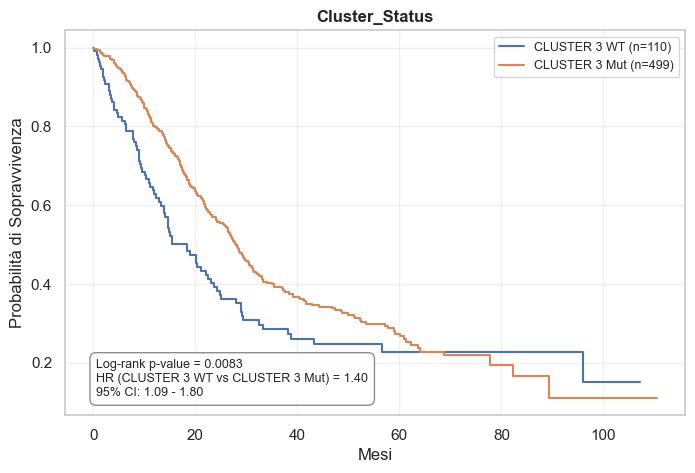

 ❌ NON SIG. | CLUSTER 4
    - P-Value: 0.29252
    - Rischio  : HR = 0.82 (95% CI: 0.57 - 1.18) [Mutati vs WT]
    - Effetto  : Nessun effetto sul rischio (Il CI include l'1 ⚪)
    - Hubs     : ['KMT2D', 'NOTCH3', 'IKBKE']
    - Pazienti : Mutati=63, Wild-Type=546
---------------------------------------------------------------------------

═══════════════════════════════════════════════════════════════════════════
 🧬 ANALISI SIGNIFICATIVITÀ CLUSTER: COLON
═══════════════════════════════════════════════════════════════════════════
 ❌ NON SIG. | CLUSTER 0
    - P-Value: 0.89951
    - Rischio  : HR = 0.99 (95% CI: 0.84 - 1.17) [Mutati vs WT]
    - Effetto  : Nessun effetto sul rischio (Il CI include l'1 ⚪)
    - Hubs     : ['PIK3CA', 'KMT2D', 'CTNNB1']
    - Pazienti : Mutati=310, Wild-Type=1017
---------------------------------------------------------------------------
 ❌ NON SIG. | CLUSTER 1
    - P-Value: 0.89028
    - Rischio  : HR = 0.98 (95% CI: 0.72 - 1.34) [Mutati vs WT]
    - Eff

<Figure size 800x500 with 0 Axes>

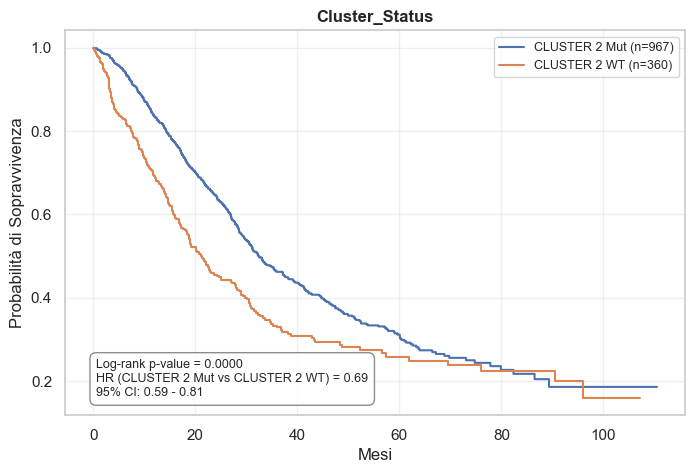

 ❌ NON SIG. | CLUSTER 3
    - P-Value: 0.19342
    - Rischio  : HR = 1.19 (95% CI: 0.91 - 1.56) [Mutati vs WT]
    - Effetto  : Nessun effetto sul rischio (Il CI include l'1 ⚪)
    - Hubs     : ['ATM', 'ATR', 'ROS1']
    - Pazienti : Mutati=93, Wild-Type=1234
---------------------------------------------------------------------------

═══════════════════════════════════════════════════════════════════════════
 🧬 ANALISI SIGNIFICATIVITÀ CLUSTER: LUNG
═══════════════════════════════════════════════════════════════════════════
 ❌ NON SIG. | CLUSTER 0
    - P-Value: 0.71412
    - Rischio  : HR = 0.97 (95% CI: 0.84 - 1.13) [Mutati vs WT]
    - Effetto  : Nessun effetto sul rischio (Il CI include l'1 ⚪)
    - Hubs     : ['NF1', 'EPHB1', 'PIK3CG']
    - Pazienti : Mutati=314, Wild-Type=1917
---------------------------------------------------------------------------
 ✅ SIGNIFICATIVO | CLUSTER 1
    - P-Value: 0.00000
    - Rischio  : HR = 1.65 (95% CI: 1.48 - 1.85) [Mutati vs WT]
    - Effetto

<Figure size 800x500 with 0 Axes>

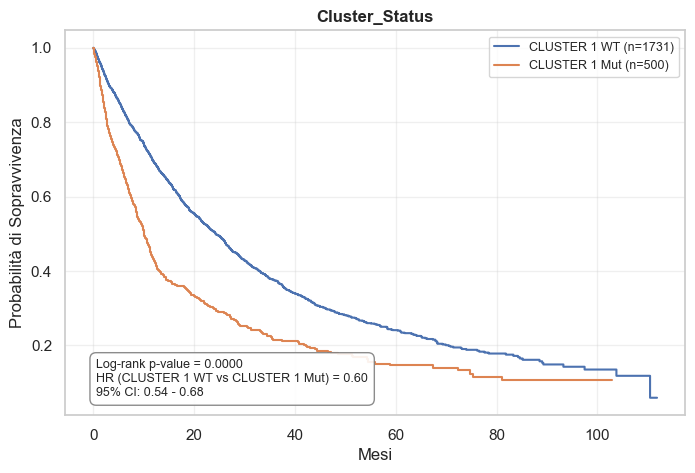

 ❌ NON SIG. | CLUSTER 2
    - P-Value: 0.28089
    - Rischio  : HR = 0.92 (95% CI: 0.80 - 1.07) [Mutati vs WT]
    - Effetto  : Nessun effetto sul rischio (Il CI include l'1 ⚪)
    - Hubs     : ['ZFHX3', 'PTPRT', 'ERBB4']
    - Pazienti : Mutati=311, Wild-Type=1920
---------------------------------------------------------------------------
 ✅ SIGNIFICATIVO | CLUSTER 3
    - P-Value: 0.00019
    - Rischio  : HR = 1.22 (95% CI: 1.10 - 1.35) [Mutati vs WT]
    - Effetto  : Rischio aumentato (Fattore prognostico negativo 🔴)
    - Hubs     : ['TP53', 'PTPRD', 'NTRK3']
    - Pazienti : Mutati=1352, Wild-Type=879
---------------------------------------------------------------------------


<Figure size 800x500 with 0 Axes>

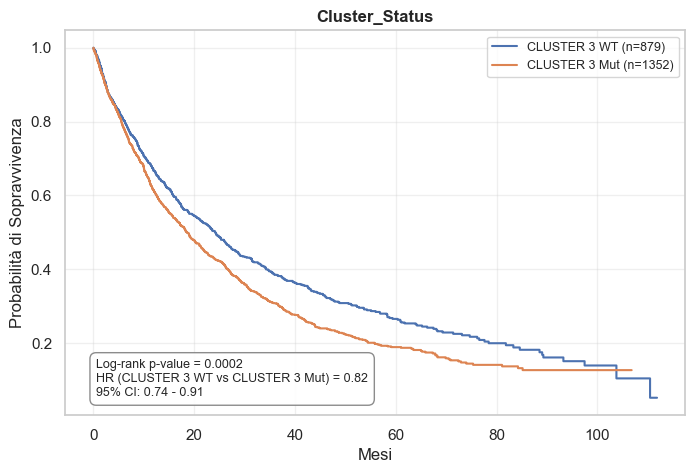

 ❌ NON SIG. | CLUSTER 4
    - P-Value: 0.09168
    - Rischio  : HR = 1.15 (95% CI: 0.98 - 1.34) [Mutati vs WT]
    - Effetto  : Nessun effetto sul rischio (Il CI include l'1 ⚪)
    - Hubs     : ['FAT1', 'PDGFRA', 'ARAF']
    - Pazienti : Mutati=243, Wild-Type=1988
---------------------------------------------------------------------------

═══════════════════════════════════════════════════════════════════════════
 🧬 ANALISI SIGNIFICATIVITÀ CLUSTER: PANCREAS
═══════════════════════════════════════════════════════════════════════════
 ❌ NON SIG. | CLUSTER 0
    - P-Value: 0.46998
    - Rischio  : HR = 1.09 (95% CI: 0.86 - 1.38) [Mutati vs WT]
    - Effetto  : Nessun effetto sul rischio (Il CI include l'1 ⚪)
    - Hubs     : ['RNF43', 'PIK3CA', 'GNAS']
    - Pazienti : Mutati=94, Wild-Type=854
---------------------------------------------------------------------------
 ❌ NON SIG. | CLUSTER 1
    - P-Value: 0.78081
    - Rischio  : HR = 0.97 (95% CI: 0.77 - 1.21) [Mutati vs WT]
    - Effe

<Figure size 800x500 with 0 Axes>

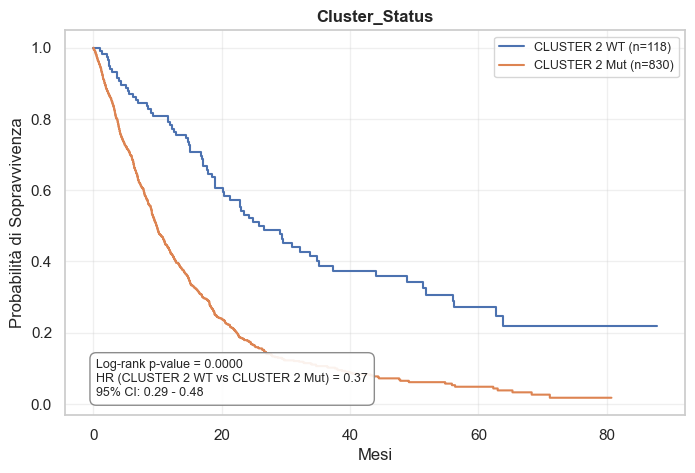

 ✅ SIGNIFICATIVO | CLUSTER 3
    - P-Value: 0.00000
    - Rischio  : HR = 0.39 (95% CI: 0.27 - 0.57) [Mutati vs WT]
    - Effetto  : Rischio ridotto (Fattore protettivo 🟢)
    - Hubs     : ['TSC2', 'MEN1', 'DAXX']
    - Pazienti : Mutati=55, Wild-Type=893
---------------------------------------------------------------------------


<Figure size 800x500 with 0 Axes>

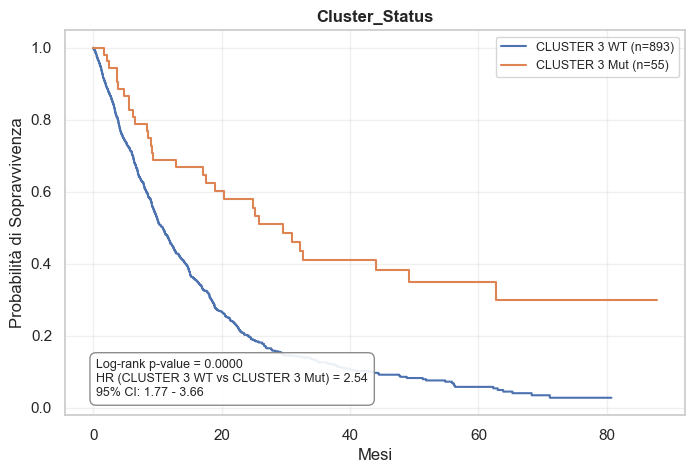

In [4]:
# =================================================================
# CELLA DIAGNOSTICA: VALIDAZIONE CLUSTER, P-VALUE E RISCHIO (HR)
# =================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from lifelines.statistics import logrank_test

def get_hubs_from_report_final(report_path):
    """Estrae i cluster e i relativi hub dal file di report .txt"""
    clusters = {}
    current_cluster = None
    if not os.path.exists(report_path):
        print(f"   [!] File report non trovato: {report_path}")
        return None
    
    with open(report_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if '🎯 CLUSTER' in line:
                current_cluster = line.split('|')[0].replace('🎯', '').strip()
                clusters[current_cluster] = []
            elif '🔸 HUB:' in line and current_cluster:
                gene = line.split(':')[1].strip()
                clusters[current_cluster].append(gene)
    return clusters

print(f"🚀 Avvio scansione clinica sui Cluster di Leiden...")

for coorte in COORTI:
    if "kras_" in coorte:
        nome_tumore = coorte.replace("kras_", "")
        path_clinical = f"./data_filtered/{coorte}/KRAS_F_{nome_tumore}.csv"
        path_report = f"./outputs_mut/{coorte}/intracluster/Report_Prof_TopHubs_FULL_{coorte}.txt"
    else:
        nome_tumore = coorte
        path_clinical = f"./data_filtered/{coorte}/F_{nome_tumore}.csv"
        path_report = f"./outputs_mut/{coorte}/intracluster/Report_Prof_TopHubs_FULL_{coorte}.txt"
    
    if os.path.exists(path_clinical):
        df_clinical = pd.read_csv(path_clinical, sep='\t')
        df_mut = load_mutation_matrix(coorte)
        cluster_data = get_hubs_from_report_final(path_report)
        
        if df_mut is not None and cluster_data:
            print(f"\n" + "═"*75)
            print(f" 🧬 ANALISI SIGNIFICATIVITÀ CLUSTER: {coorte.upper()}")
            print("═"*75)

            for cluster_name, genes in cluster_data.items():
                valid_genes = [g for g in genes if g in df_mut.columns]
                
                if valid_genes:
                    df_c = df_clinical.copy()
                    df_c['Sample_Id'] = df_c['Sample_Id'].astype(str)
                    
                    time_col = 'Overall Survival (Months)'
                    status_col = 'Overall Survival Status'
                    
                    df_c = df_c.dropna(subset=[time_col, status_col])
                    df_c['Time'] = pd.to_numeric(df_c[time_col], errors='coerce')
                    df_c['Event'] = df_c[status_col].apply(lambda x: 1 if '1:DECEASED' in str(x).upper() else 0)
                    df_c = df_c.dropna(subset=['Time'])

                    mut_indices = df_mut[df_mut[valid_genes].sum(axis=1) > 0].index
                    mask_mut = df_c['Sample_Id'].isin(mut_indices)
                    
                    df_c['Cluster_Status'] = np.where(mask_mut, f"{cluster_name} Mut", f"{cluster_name} WT")
                    
                    group_mut = df_c[mask_mut]
                    group_wt = df_c[~mask_mut]

                    if len(group_mut) >= 5 and len(group_wt) >= 5:
                        # 1. Log-Rank Test
                        results = logrank_test(group_mut['Time'], group_wt['Time'], 
                                               event_observed_A=group_mut['Event'], 
                                               event_observed_B=group_wt['Event'])
                        p_value = results.p_value
                        sig_status = "✅ SIGNIFICATIVO" if p_value < 0.05 else "❌ NON SIG."
                        
                        # 2. Modello di Cox (Hazard Ratio) e Interpretazione
                        try:
                            df_cox = df_c[['Cluster_Status', 'Time', 'Event']].copy()
                            df_cox['Group_Num'] = np.where(df_cox['Cluster_Status'] == f"{cluster_name} Mut", 1, 0)
                            cph = CoxPHFitter()
                            cph.fit(df_cox[['Group_Num', 'Time', 'Event']], duration_col='Time', event_col='Event')
                            
                            hr = cph.summary.loc['Group_Num', 'exp(coef)']
                            ci_l = cph.summary.loc['Group_Num', 'exp(coef) lower 95%']
                            ci_u = cph.summary.loc['Group_Num', 'exp(coef) upper 95%']
                            hr_text = f"HR = {hr:.2f} (95% CI: {ci_l:.2f} - {ci_u:.2f})"
                            
                            # --- NUOVA LOGICA DI INTERPRETAZIONE ---
                            if ci_l > 1.0:
                                interpretazione = "Rischio aumentato (Fattore prognostico negativo 🔴)"
                            elif ci_u < 1.0:
                                interpretazione = "Rischio ridotto (Fattore protettivo 🟢)"
                            else:
                                interpretazione = "Nessun effetto sul rischio (Il CI include l'1 ⚪)"
                                
                        except Exception:
                            hr_text = "HR non calcolabile"
                            interpretazione = "Non valutabile"

                        # Stampa a schermo
                        print(f" {sig_status} | {cluster_name}")
                        print(f"    - P-Value: {p_value:.5f}")
                        print(f"    - Rischio  : {hr_text} [Mutati vs WT]")
                        print(f"    - Effetto  : {interpretazione}")  # <--- STAMPA L'INTERPRETAZIONE
                        print(f"    - Hubs     : {valid_genes}")
                        print(f"    - Pazienti : Mutati={len(group_mut)}, Wild-Type={len(group_wt)}")
                        print("-" * 75)
                        
                        # Decommenta qui sotto per stampare i grafici per i cluster significativi
                        if p_value < 0.05:
                             plt.figure(figsize=(8, 5))
                             plot_kaplan_meier(df_c, group_col='Cluster_Status')
                             plt.show()
                        
                    else:
                        print(f" ⚠️ {cluster_name}: Pazienti insufficienti per statistica affidabile (Mut={len(group_mut)}, WT={len(group_wt)}).")
                        print("-" * 75)
                else:
                    print(f" ⚠️ {cluster_name}: Nessun Hub del report trovato in matrice.")
                    print("-" * 75)
    else:
        print(f"❌ File clinico non trovato in {path_clinical}")

# SIGNIFICATIVITA' FEATURE

In [5]:
# ==========================================
# TOOL DI RICERCA AUTOMATICA FEATURE SIGNIFICATIVE
# ==========================================

import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
from lifelines.statistics import logrank_test

def find_significant_features(df_clinical, features_list, time_col='Overall Survival (Months)', status_col='Overall Survival Status'):
    """
    Scansiona una lista di feature cliniche e stampa un report SOLO per quelle 
    che mostrano una sopravvivenza statisticamente significativa (p < 0.05).
    """
    df_base = df_clinical.copy()
    df_base.columns = df_base.columns.str.strip()
    
    # Controllo se le colonne di sopravvivenza esistono nel dataset
    if time_col not in df_base.columns or status_col not in df_base.columns:
        print(f"   [!] Colonne di sopravvivenza non trovate in questo dataset.")
        return

    df_base['Time'] = pd.to_numeric(df_base[time_col], errors='coerce')
    df_base['Event'] = df_base[status_col].apply(lambda x: 1 if '1:DECEASED' in str(x).upper() else 0)
    df_base = df_base.dropna(subset=['Time'])
    
    significant_found = False

    for feature in features_list:
        if feature not in df_base.columns:
            continue
            
        df_feat = df_base.dropna(subset=[feature, 'Time', 'Event']).copy()
        
        # Filtro Statistico: Teniamo solo i gruppi con almeno 10 pazienti
        group_counts = df_feat[feature].value_counts()
        valid_groups = group_counts[group_counts >= 10].index
        df_feat = df_feat[df_feat[feature].isin(valid_groups)]
        
        groups = df_feat[feature].unique()
        
        # Procediamo solo se abbiamo esattamente 2 gruppi validi
        if len(groups) == 2:
            g1, g0 = groups[0], groups[1]
            mask1, mask0 = (df_feat[feature] == g1), (df_feat[feature] == g0)
            t1, e1 = df_feat[mask1]['Time'], df_feat[mask1]['Event']
            t0, e0 = df_feat[mask0]['Time'], df_feat[mask0]['Event']
            
            # Log-rank test
            res = logrank_test(t1, t0, event_observed_A=e1, event_observed_B=e0)
            
            if res.p_value < 0.05:
                significant_found = True
                df_cox = df_feat[[feature, 'Time', 'Event']].copy()
                df_cox['Group_Num'] = np.where(df_cox[feature] == g1, 1, 0)
                
                try:
                    cph = CoxPHFitter()
                    cph.fit(df_cox[['Group_Num', 'Time', 'Event']], duration_col='Time', event_col='Event')
                    hr = cph.summary.loc['Group_Num', 'exp(coef)']
                    ci_l = cph.summary.loc['Group_Num', 'exp(coef) lower 95%']
                    ci_u = cph.summary.loc['Group_Num', 'exp(coef) upper 95%']
                    hr_text = f"HR = {hr:.2f} (95% CI: {ci_l:.2f} - {ci_u:.2f})"
                    
                    # --- NUOVA LOGICA DI INTERPRETAZIONE ---
                    if ci_l > 1.0:
                        interpretazione = "Rischio aumentato (Fattore prognostico negativo 🔴)"
                    elif ci_u < 1.0:
                        interpretazione = "Rischio ridotto (Fattore protettivo 🟢)"
                    else:
                        interpretazione = "Nessun effetto netto (Il CI include l'1 ⚪)"
                        
                except Exception:
                    hr_text = "HR non calcolabile"
                    interpretazione = "Non valutabile"
                    
                print(f"✅ FEATURE: {feature}")
                print(f"   ► P-value (Log-rank) : {res.p_value:.5f} ⭐")
                print(f"   ► Rischio (Cox)      : {hr_text} [{g1} vs {g0}]")
                print(f"   ► Effetto            : {interpretazione}") # <--- LA NUOVA RIGA MAGICA
                print(f"   ► Distribuzione      : {g1} (n={len(t1)}) vs {g0} (n={len(t0)})")
                print("-" * 70)
                
    if not significant_found:
        print("❌ Nessuna delle feature testate ha mostrato differenze significative in questa coorte.")

# ESECUZIONE RICERCA CLINICA

In [ ]:
# ==========================================
# ESECUZIONE DELLA RICERCA: CLINICA + FASCIE GENOMICHE
# ==========================================

# 1. Le colonne pronte all'uso + le 3 nuove che creeremo
colonne_da_testare = [
    'Sex', 
    'Stage (Highest Recorded)', 
    'Smoking History (NLP)', 
    'Prior Treatment to MSK (NLP)',
    'MSI Type',
    'Sample Type',
    'Age_Group',  
    'TMB_Group',  
    'FGA_Group'  
]

print("🚀 AVVIO RICERCA AUTOMATICA MULTI-PARAMETRICA (p-value < 0.05)")

# 2. Ciclo automatico sulle coorti
for coorte in COORTI:
    if "kras_" in coorte:
        coorte_base = coorte.replace("kras_", "")
        path_clinical = f"./data_filtered/{coorte}/KRAS_F_{coorte_base}.csv"
    else:
        coorte_base = coorte
        path_clinical = f"./data_filtered/{coorte}/F_{coorte_base}.csv"
    
    if os.path.exists(path_clinical):
        df_clinical = pd.read_csv(path_clinical, sep='\t')
        
        # --- 3. CREAZIONE AUTOMATICA DELLE 3 FASCE NUMERICHE SULLA MEDIANA ---
        
        # A. Fasce d'Età con Cut-off Clinico (es. 65 anni)
        if 'Current Age' in df_clinical.columns:
            df_clinical['Age_Num'] = pd.to_numeric(df_clinical['Current Age'], errors='coerce')
            
            # Usiamo np.where per creare una regola fissa: chi ha >= 65 anni da una parte, gli altri dall'altra
            import numpy as np
            df_clinical['Age_Group'] = np.where(df_clinical['Age_Num'] >= 65, '>= 65 Years', '< 65 Years')
            
            # Pulizia per sicurezza: se l'età mancava, rimettiamo a NaN
            df_clinical.loc[df_clinical['Age_Num'].isna(), 'Age_Group'] = np.nan
            
        # B. Fasce di Tumor Mutational Burden (TMB)
        if 'TMB (nonsynonymous)' in df_clinical.columns:
            df_clinical['TMB_Num'] = pd.to_numeric(df_clinical['TMB (nonsynonymous)'], errors='coerce')
            df_clinical['TMB_Group'] = pd.qcut(df_clinical['TMB_Num'], q=2, labels=['Low TMB', 'High TMB'])
            
        # C. Fasce di Fraction Genome Altered (FGA)
        if 'Fraction Genome Altered' in df_clinical.columns:
            df_clinical['FGA_Num'] = pd.to_numeric(df_clinical['Fraction Genome Altered'], errors='coerce')
            df_clinical['FGA_Group'] = pd.qcut(df_clinical['FGA_Num'], q=2, labels=['Low FGA', 'High FGA'])
        
        # ----------------------------------------------------------------------
        
        print("\n" + "═" * 70)
        print(f" 🔍 SCANSIONE COORTE: {coorte.upper()}")
        print("═" * 70)
        
        # Avvia il radar!
        find_significant_features(df_clinical, colonne_da_testare)
    else:
        print(f"\n[-] File clinico non trovato per la coorte {coorte}: {path_clinical}")

🚀 AVVIO RICERCA AUTOMATICA MULTI-PARAMETRICA (p-value < 0.05)

══════════════════════════════════════════════════════════════════════
 🔍 SCANSIONE COORTE: KRAS_PANCREAS
══════════════════════════════════════════════════════════════════════
✅ FEATURE: FGA_Group
   ► P-value (Log-rank) : 0.00097 ⭐
   ► Rischio (Cox)      : HR = 0.77 (95% CI: 0.67 - 0.90) [Low FGA vs High FGA]
   ► Effetto            : Rischio ridotto (Fattore protettivo 🟢)
   ► Distribuzione      : Low FGA (n=405) vs High FGA (n=405)
----------------------------------------------------------------------

══════════════════════════════════════════════════════════════════════
 🔍 SCANSIONE COORTE: KRAS_LUNG
══════════════════════════════════════════════════════════════════════
✅ FEATURE: Sample Type
   ► P-value (Log-rank) : 0.03688 ⭐
   ► Rischio (Cox)      : HR = 0.82 (95% CI: 0.68 - 0.99) [Primary vs Metastasis]
   ► Effetto            : Rischio ridotto (Fattore protettivo 🟢)
   ► Distribuzione      : Primary (n=260) vs 

# SALVATAGGIO FILE

In [7]:
import os
from contextlib import redirect_stdout

# ==========================================
# SALVATAGGIO RISULTATI IN FILE DI TESTO
# ==========================================


# Percorso del file di report
report_path = "./survival_report.txt"

with open(report_path, 'w') as f:
    with redirect_stdout(f):
        print("REPORT COMPLETO: ANALISI CLUSTERS E FEATURE CLINICHE")
        print("=" * 80)
        
        # Copia del codice da CELL INDEX: 4 per salvare risultati clusters
        print("\nANALISI SIGNIFICATIVITÀ CLUSTER:")
        print("-" * 50)
        
        for coorte in COORTI:
            if "kras_" in coorte:
                nome_tumore = coorte.replace("kras_", "")
                path_clinical = f"./data_filtered/{coorte}/KRAS_F_{nome_tumore}.csv"
                path_report = f"./outputs_mut/{coorte}/intracluster/Report_Prof_TopHubs_FULL_{coorte}.txt"
            else:
                nome_tumore = coorte
                path_clinical = f"./data_filtered/{coorte}/F_{nome_tumore}.csv"
                path_report = f"./outputs_mut/{coorte}/intracluster/Report_Prof_TopHubs_FULL_{coorte}.txt"
            
            if os.path.exists(path_clinical):
                df_clinical = pd.read_csv(path_clinical, sep='\t')
                df_mut = load_mutation_matrix(coorte)
                cluster_data = get_hubs_from_report_final(path_report)
                
                if df_mut is not None and cluster_data:
                    print(f"\n" + "═"*75)
                    print(f" 🧬 ANALISI SIGNIFICATIVITÀ CLUSTER: {coorte.upper()}")
                    print("═"*75)

                    for cluster_name, genes in cluster_data.items():
                        valid_genes = [g for g in genes if g in df_mut.columns]
                        
                        if valid_genes:
                            df_c = df_clinical.copy()
                            df_c['Sample_Id'] = df_c['Sample_Id'].astype(str)
                            
                            time_col = 'Overall Survival (Months)'
                            status_col = 'Overall Survival Status'
                            
                            df_c = df_c.dropna(subset=[time_col, status_col])
                            df_c['Time'] = pd.to_numeric(df_c[time_col], errors='coerce')
                            df_c['Event'] = df_c[status_col].apply(lambda x: 1 if '1:DECEASED' in str(x).upper() else 0)
                            df_c = df_c.dropna(subset=['Time'])

                            mut_indices = df_mut[df_mut[valid_genes].sum(axis=1) > 0].index
                            mask_mut = df_c['Sample_Id'].isin(mut_indices)
                            
                            df_c['Cluster_Status'] = np.where(mask_mut, f"{cluster_name} Mut", f"{cluster_name} WT")
                            
                            group_mut = df_c[mask_mut]
                            group_wt = df_c[~mask_mut]

                            if len(group_mut) >= 5 and len(group_wt) >= 5:
                                # 1. Log-Rank Test
                                results = logrank_test(group_mut['Time'], group_wt['Time'], 
                                                       event_observed_A=group_mut['Event'], 
                                                       event_observed_B=group_wt['Event'])
                                p_value = results.p_value
                                sig_status = "✅ SIGNIFICATIVO" if p_value < 0.05 else "❌ NON SIG."
                                
                                # 2. Modello di Cox (Hazard Ratio) e Interpretazione
                                try:
                                    df_cox = df_c[['Cluster_Status', 'Time', 'Event']].copy()
                                    df_cox['Group_Num'] = np.where(df_cox['Cluster_Status'] == f"{cluster_name} Mut", 1, 0)
                                    cph = CoxPHFitter()
                                    cph.fit(df_cox[['Group_Num', 'Time', 'Event']], duration_col='Time', event_col='Event')
                                    
                                    hr = cph.summary.loc['Group_Num', 'exp(coef)']
                                    ci_l = cph.summary.loc['Group_Num', 'exp(coef) lower 95%']
                                    ci_u = cph.summary.loc['Group_Num', 'exp(coef) upper 95%']
                                    hr_text = f"HR = {hr:.2f} (95% CI: {ci_l:.2f} - {ci_u:.2f})"
                                    
                                    # --- NUOVA LOGICA DI INTERPRETAZIONE ---
                                    if ci_l > 1.0:
                                        interpretazione = "Rischio aumentato (Fattore prognostico negativo 🔴)"
                                    elif ci_u < 1.0:
                                        interpretazione = "Rischio ridotto (Fattore protettivo 🟢)"
                                    else:
                                        interpretazione = "Nessun effetto sul rischio (Il CI include l'1 ⚪)"
                                        
                                except Exception:
                                    hr_text = "HR non calcolabile"
                                    interpretazione = "Non valutabile"

                                # Stampa a schermo
                                print(f" {sig_status} | {cluster_name}")
                                print(f"    - P-Value: {p_value:.5f}")
                                print(f"    - Rischio  : {hr_text} [Mutati vs WT]")
                                print(f"    - Effetto  : {interpretazione}")  # <--- STAMPA L'INTERPRETAZIONE
                                print(f"    - Hubs     : {valid_genes}")
                                print(f"    - Pazienti : Mutati={len(group_mut)}, Wild-Type={len(group_wt)}")
                                print("-" * 75)
                                
                            else:
                                print(f" ⚠️ {cluster_name}: Pazienti insufficienti per statistica affidabile (Mut={len(group_mut)}, WT={len(group_wt)}).")
                                print("-" * 75)
                        else:
                            print(f" ⚠️ {cluster_name}: Nessun Hub del report trovato in matrice.")
                            print("-" * 75)
            else:
                print(f"❌ File clinico non trovato in {path_clinical}")
        
        # Copia del codice da CELL INDEX: 6 per salvare risultati feature cliniche
        print("\n\nANALISI FEATURE CLINICHE SIGNIFICATIVE:")
        print("-" * 50)
        
        colonne_da_testare = [
            'Sex', 
            'Stage (Highest Recorded)', 
            'Smoking History (NLP)', 
            'Prior Treatment to MSK (NLP)',
            'MSI Type',
            'Sample Type',
            'Age_Group',  # <-- Creata in automatico sotto
            'TMB_Group',  # <-- Creata in automatico sotto
            'FGA_Group'   # <-- Creata in automatico sotto
        ]

        print("🚀 AVVIO RICERCA AUTOMATICA MULTI-PARAMETRICA (p-value < 0.05)")

        # 2. Ciclo automatico sulle coorti
        for coorte in COORTI:
            if "kras_" in coorte:
                coorte_base = coorte.replace("kras_", "")
                path_clinical = f"./data_filtered/{coorte}/KRAS_F_{coorte_base}.csv"
            else:
                coorte_base = coorte
                path_clinical = f"./data_filtered/{coorte}/F_{coorte_base}.csv"
            
            if os.path.exists(path_clinical):
                df_clinical = pd.read_csv(path_clinical, sep='\t')
                
                # --- 3. CREAZIONE AUTOMATICA DELLE 3 FASCE NUMERICHE SULLA MEDIANA ---
                
                # A. Fasce d'Età con Cut-off Clinico (es. 65 anni)
                if 'Current Age' in df_clinical.columns:
                    df_clinical['Age_Num'] = pd.to_numeric(df_clinical['Current Age'], errors='coerce')
                    
                    # Usiamo np.where per creare una regola fissa: chi ha >= 65 anni da una parte, gli altri dall'altra
                    df_clinical['Age_Group'] = np.where(df_clinical['Age_Num'] >= 65, '>= 65 Years', '< 65 Years')
                    
                    # Pulizia per sicurezza: se l'età mancava, rimettiamo a NaN
                    df_clinical.loc[df_clinical['Age_Num'].isna(), 'Age_Group'] = np.nan
                    
                # B. Fasce di Tumor Mutational Burden (TMB)
                if 'TMB (nonsynonymous)' in df_clinical.columns:
                    df_clinical['TMB_Num'] = pd.to_numeric(df_clinical['TMB (nonsynonymous)'], errors='coerce')
                    df_clinical['TMB_Group'] = pd.qcut(df_clinical['TMB_Num'], q=2, labels=['Low TMB', 'High TMB'])
                    
                # C. Fasce di Fraction Genome Altered (FGA)
                if 'Fraction Genome Altered' in df_clinical.columns:
                    df_clinical['FGA_Num'] = pd.to_numeric(df_clinical['Fraction Genome Altered'], errors='coerce')
                    df_clinical['FGA_Group'] = pd.qcut(df_clinical['FGA_Num'], q=2, labels=['Low FGA', 'High FGA'])
                
                # ----------------------------------------------------------------------
                
                print("\n" + "═" * 70)
                print(f" 🔍 SCANSIONE COORTE: {coorte.upper()}")
                print("═" * 70)
                
                # Avvia il radar!
                find_significant_features(df_clinical, colonne_da_testare)
            else:
                print(f"\n[-] File clinico non trovato per la coorte {coorte}: {path_clinical}")

print(f"✅ Report salvato in: {report_path}")

✅ Report salvato in: ./survival_report.txt
